1. Setup Awal

In [1]:
# Memastikan Python yang digunakan adalah versi 3.5 atau lebih tinggi
import sys
assert sys.version_info >= (3, 5)

# Memastikan Scikit-Learn yang digunakan adalah versi 0.20 atau lebih tinggi
import sklearn
assert sklearn.__version__ >= "0.20"

# Import library umum yang akan digunakan
import numpy as np
import os
import pandas as pd

# Untuk membuat plot/grafik
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

2. Mengunduh Data

In [2]:
import os
import tarfile
import urllib.request

# Alamat URL tempat data berada
DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
HOUSING_PATH = os.path.join("datasets", "housing")
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"

# Fungsi untuk mengambil dan mengekstrak data
def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    if not os.path.isdir(housing_path):
        os.makedirs(housing_path)
    tgz_path = os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(housing_url, tgz_path)
    housing_tgz = tarfile.open(tgz_path)
    housing_tgz.extractall(path=housing_path)
    housing_tgz.close()

# Memanggil fungsi untuk mengunduh data
fetch_housing_data()

3. Memuat & Eksplorasi Data Awal

5 baris pertama data:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY



Informasi Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB

Statistik Deskriptif:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


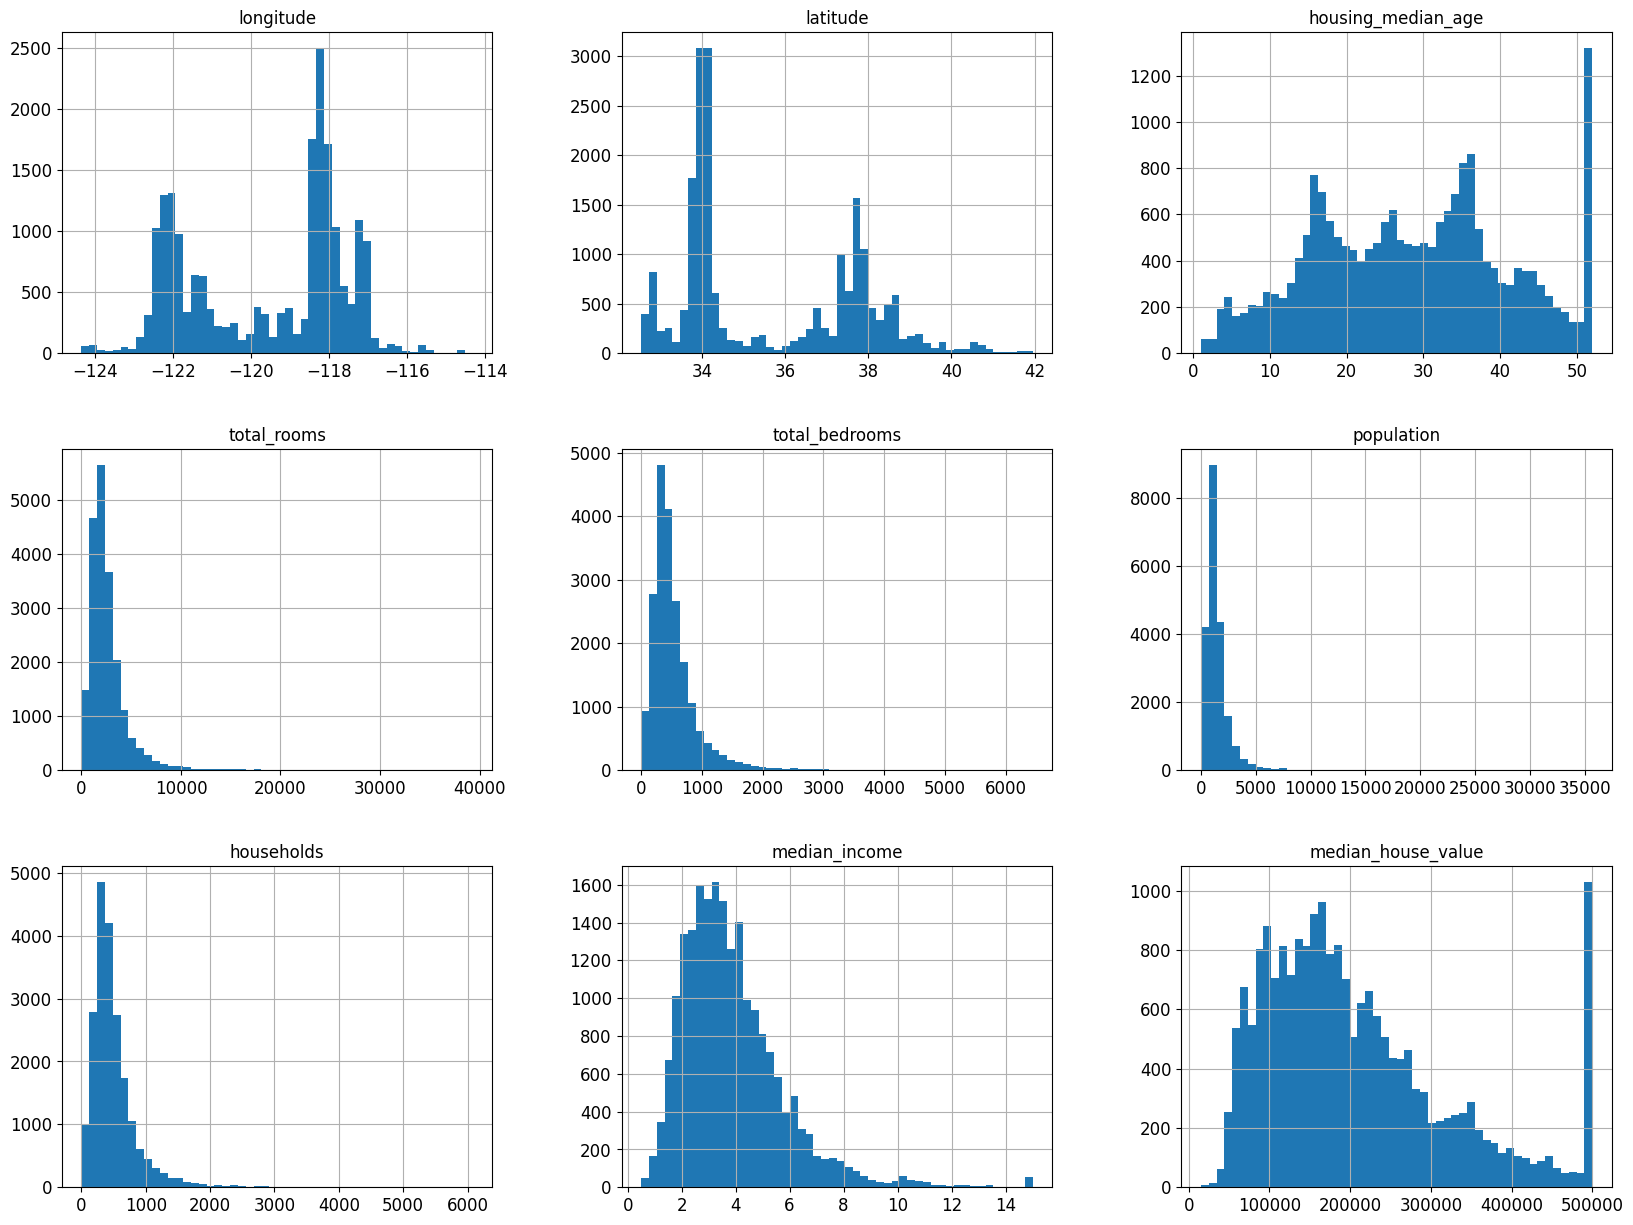

In [3]:
# Fungsi untuk memuat data CSV
def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

# Memuat data ke dalam DataFrame
housing = load_housing_data()

# Menampilkan 5 baris pertama
print("5 baris pertama data:")
display(housing.head())

# Menampilkan informasi ringkas tentang data (tipe data, data kosong, dll.)
print("\nInformasi Data:")
housing.info()

# Menampilkan statistik deskriptif (rata-rata, std, dll.) untuk kolom numerik
print("\nStatistik Deskriptif:")
display(housing.describe())

# Membuat histogram untuk semua kolom numerik untuk melihat distribusinya
housing.hist(bins=50, figsize=(20,15))
plt.show()

4. Membuat Test Set (Stratified Sampling)

In [4]:
from sklearn.model_selection import StratifiedShuffleSplit

# Membuat kategori pendapatan agar sampling lebih representatif
housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

# Melakukan splitting (pemisahan data)
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

# Menghapus kolom 'income_cat' karena hanya untuk splitting
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

# Membuat copy dari data training untuk eksplorasi lebih lanjut
housing = strat_train_set.copy()

 5. Visualisasi Data untuk Mencari Wawasan

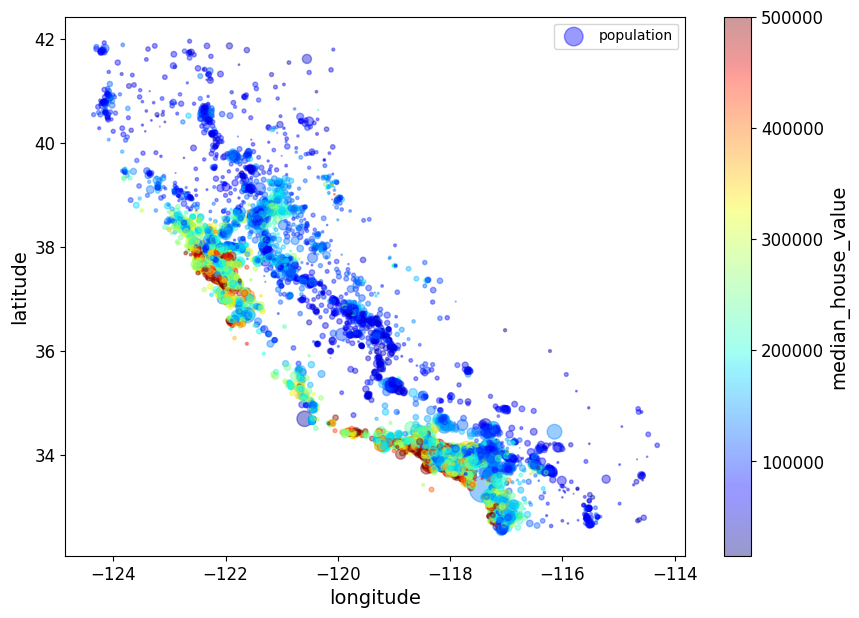

In [5]:
# Scatter plot untuk melihat data geografis
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
             s=housing["population"]/100, label="population", figsize=(10,7),
             c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
             sharex=False)
plt.legend()
plt.show()

6. Mencari Korelasi

median_house_value    1.000000
median_income         0.687151
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64


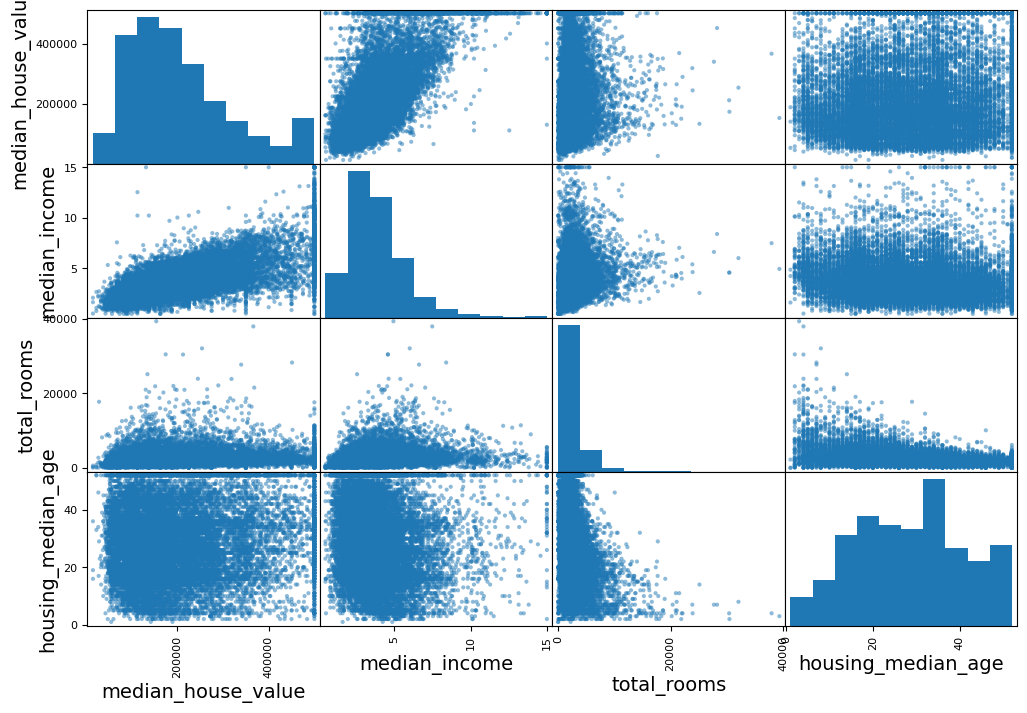

In [6]:
# Menghitung korelasi standar (koefisien Pearson)
corr_matrix = housing.corr(numeric_only=True)

# Melihat korelasi kolom 'median_house_value' dengan kolom lainnya
print(corr_matrix["median_house_value"].sort_values(ascending=False))

# Membuat scatter matrix untuk melihat korelasi antar beberapa atribut
from pandas.plotting import scatter_matrix
attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))
plt.show()

7. Feature Engineering

In [7]:
# Membuat atribut baru dari kombinasi atribut yang ada
housing["rooms_per_household"] = housing["total_rooms"]/housing["households"]
housing["bedrooms_per_room"] = housing["total_bedrooms"]/housing["total_rooms"]
housing["population_per_household"]=housing["population"]/housing["households"]

# Memeriksa korelasi lagi dengan atribut baru
corr_matrix = housing.corr(numeric_only=True)
print(corr_matrix["median_house_value"].sort_values(ascending=False))

median_house_value          1.000000
median_income               0.687151
rooms_per_household         0.146255
total_rooms                 0.135140
housing_median_age          0.114146
households                  0.064590
total_bedrooms              0.047781
population_per_household   -0.021991
population                 -0.026882
longitude                  -0.047466
latitude                   -0.142673
bedrooms_per_room          -0.259952
Name: median_house_value, dtype: float64


 8. Mempersiapkan Data untuk Model (Data Preprocessing)

In [8]:
# Memisahkan kembali fitur (predictors) dan label (target)
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

# 1. Mengisi data numerik yang kosong dengan Imputer
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
housing_num = housing.drop("ocean_proximity", axis=1) # Hanya data numerik
imputer.fit(housing_num)
X = imputer.transform(housing_num)
housing_tr = pd.DataFrame(X, columns=housing_num.columns, index=housing.index)

# 2. Mengubah data kategori menjadi angka
from sklearn.preprocessing import OneHotEncoder
housing_cat = housing[["ocean_proximity"]]
cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

9. Membangun Pipeline Transformasi

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# Pipeline untuk atribut numerik
num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy="median")),
        ('std_scaler', StandardScaler()),
    ])

# Menggabungkan pipeline numerik dan transformer kategori
num_attribs = list(housing_num)
cat_attribs = ["ocean_proximity"]

full_pipeline = ColumnTransformer([
        ("num", num_pipeline, num_attribs),
        ("cat", OneHotEncoder(), cat_attribs),
    ])

# Menjalankan seluruh pipeline pada data
housing_prepared = full_pipeline.fit_transform(housing)

10. Memilih dan Melatih Model

In [10]:
# 1. Model Regresi Linier
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)

# 2. Model Decision Tree
from sklearn.tree import DecisionTreeRegressor
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(housing_prepared, housing_labels)

# 3. Model Random Forest
from sklearn.ensemble import RandomForestRegressor
forest_reg = RandomForestRegressor(n_estimators=100, random_state=42)
forest_reg.fit(housing_prepared, housing_labels)

RandomForestRegressor(random_state=42)

11. Evaluasi Model dengan Cross-Validation

In [11]:
from sklearn.model_selection import cross_val_score

# Evaluasi Decision Tree
scores = cross_val_score(tree_reg, housing_prepared, housing_labels,
                         scoring="neg_mean_squared_error", cv=10)
tree_rmse_scores = np.sqrt(-scores)

# Evaluasi Linear Regression
scores = cross_val_score(lin_reg, housing_prepared, housing_labels,
                         scoring="neg_mean_squared_error", cv=10)
lin_rmse_scores = np.sqrt(-scores)

# Evaluasi Random Forest
scores = cross_val_score(forest_reg, housing_prepared, housing_labels,
                         scoring="neg_mean_squared_error", cv=10)
forest_rmse_scores = np.sqrt(-scores)

# Menampilkan rata-rata dan standar deviasi error (RMSE) dari setiap model
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

print("--- Decision Tree ---")
display_scores(tree_rmse_scores)
print("\n--- Linear Regression ---")
display_scores(lin_rmse_scores)
print("\n--- Random Forest ---")
display_scores(forest_rmse_scores)

--- Decision Tree ---
Scores: [71177.6601991  69770.07865373 64770.5639395  68536.60203993
 67057.08155801 68847.12456973 70977.38255647 69208.86346929
 67187.87131535 73280.38732407]
Mean: 69081.361562518
Standard deviation: 2296.288087393378

--- Linear Regression ---
Scores: [72229.03469752 65318.2240289  67706.39604745 69368.53738998
 66767.61061621 73003.75273869 70522.24414582 69440.77896541
 66930.32945876 70756.31946074]
Mean: 69204.32275494763
Standard deviation: 2372.070791055922

--- Random Forest ---
Scores: [51039.08053738 48741.94041426 45940.42771745 50501.41453432
 47387.7896427  49595.25845731 51625.68567717 48865.70709952
 47322.87631489 53301.08748462]
Mean: 49432.12678796127
Standard deviation: 2124.8587921578355


12. Fine-Tuning Model (Mencari Hyperparameter Terbaik)

In [12]:
from sklearn.model_selection import GridSearchCV

# Daftar parameter yang akan diuji untuk Random Forest
param_grid = [
    {'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]},
    {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},
  ]

forest_reg = RandomForestRegressor(random_state=42)

# Mencari kombinasi parameter terbaik dengan GridSearchCV
grid_search = GridSearchCV(forest_reg, param_grid, cv=5,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)
grid_search.fit(housing_prepared, housing_labels)

print("Parameter terbaik:", grid_search.best_params_)

Parameter terbaik: {'max_features': 8, 'n_estimators': 30}


13. Evaluasi Final pada Test Set

In [13]:
# Mengambil model terbaik dari hasil GridSearch
final_model = grid_search.best_estimator_

# Memisahkan fitur dan label dari data test
X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

# Menjalankan pipeline transformasi pada data test (hanya .transform, bukan .fit_transform)
X_test_prepared = full_pipeline.transform(X_test)

# Membuat prediksi pada data test
final_predictions = final_model.predict(X_test_prepared)

# Menghitung error final (RMSE)
from sklearn.metrics import mean_squared_error
final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)

print("Final RMSE on test set:", final_rmse)

Final RMSE on test set: 47859.544319108194


Berikut adalah penjelasan untuk setiap bagian kode di atas:

Bagian 1: Setup Awal: Sama seperti chapter sebelumnya, bagian ini menyiapkan semua library yang dibutuhkan seperti pandas untuk manipulasi data, numpy untuk komputasi numerik, dan matplotlib untuk visualisasi.

Bagian 2: Mengunduh Data: Kode ini membuat sebuah fungsi fetch_housing_data untuk mengunduh file data terkompresi (.tgz) dari internet, lalu mengekstraknya secara otomatis. Ini adalah cara yang baik untuk memastikan data selalu tersedia.

Bagian 3: Memuat & Eksplorasi Data Awal: Ini adalah langkah pertama dalam setiap proyek data. Kita memuat data (housing.csv) dan menggunakan .head() untuk mengintip isinya, .info() untuk memeriksa tipe data dan nilai yang hilang (missing values), .describe() untuk mendapatkan statistik dasar, dan .hist() untuk melihat distribusi setiap fitur.

Bagian 4: Membuat Test Set: Ini adalah langkah paling krusial. Kita harus memisahkan sebagian data (20%) untuk pengujian akhir (test set). Data ini tidak boleh disentuh selama proses eksplorasi dan pelatihan model. Kode ini menggunakan StratifiedShuffleSplit yang lebih canggih dari sekadar acak biasa. Metode ini memastikan bahwa proporsi "kategori pendapatan" (income_cat) di data latih dan data tes sama, sehingga set tes kita benar-benar representatif.

Bagian 5: Visualisasi Data: Kita membuat scatter plot geografis dari data. Dengan mengatur transparansi (alpha), kita bisa melihat area dengan kepadatan populasi tinggi. Ukuran titik (s) merepresentasikan populasi, dan warna (c dan cmap) merepresentasikan harga rumah. Ini membantu kita melihat pola, seperti harga rumah yang cenderung lebih mahal di dekat pantai.

Bagian 6: Mencari Korelasi: Kita menghitung koefisien korelasi Pearson untuk melihat seberapa kuat hubungan linier antar fitur. Nilai mendekati 1 berarti korelasi positif kuat, dan mendekati -1 berarti korelasi negatif kuat. scatter_matrix membantu memvisualisasikan korelasi ini untuk beberapa atribut pilihan.

Bagian 7: Feature Engineering: Ini adalah proses membuat fitur baru dari fitur yang sudah ada, dengan harapan fitur baru ini memiliki korelasi yang lebih baik dengan target. Contohnya, kita membuat fitur rooms_per_household (jumlah kamar per rumah tangga) yang ternyata lebih informatif daripada total_rooms saja.

Bagian 8: Data Preprocessing: Model machine learning tidak bisa memproses data yang "kotor". Di sini kita melakukan:

Imputer: Mengisi nilai yang hilang (kosong) di kolom numerik dengan nilai median.

OneHotEncoder: Mengubah data kategori (seperti ocean_proximity) menjadi format biner (0 dan 1) yang bisa dimengerti oleh model.

Bagian 9: Membangun Pipeline: Untuk menyederhanakan proses preprocessing, kita menggunakan Pipeline. Ini adalah sebuah alur kerja yang menggabungkan beberapa langkah (seperti imputer dan scaler) menjadi satu. ColumnTransformer digunakan untuk menerapkan pipeline yang berbeda pada jenis kolom yang berbeda (numerik vs. kategori).

Bagian 10 & 11: Memilih, Melatih, dan Evaluasi Model: Kita mencoba tiga model berbeda (Regresi Linier, Decision Tree, Random Forest) untuk melihat mana yang performanya paling baik. Daripada hanya mengandalkan satu set validasi, kita menggunakan Cross-Validation. Metode ini membagi data latih menjadi 10 bagian, lalu melatih dan mengevaluasi model sebanyak 10 kali, sehingga kita mendapatkan estimasi performa yang lebih stabil dan tepercaya.

Bagian 12: Fine-Tuning Model: Setelah memilih model terbaik (dalam kasus ini, Random Forest), kita mencoba mencari hyperparameter terbaik untuk model tersebut. Hyperparameter adalah "pengaturan" model yang tidak bisa dipelajari dari data (misalnya, n_estimators). GridSearchCV secara otomatis mencoba semua kombinasi hyperparameter yang kita berikan dan menemukan yang menghasilkan error terkecil.

Bagian 13: Evaluasi Final pada Test Set: Ini adalah momen kebenaran. Setelah kita memiliki model final yang sudah di-tuning, kita gunakan test set yang dari awal kita simpan. Kita ukur performa model pada data ini untuk mendapatkan estimasi seberapa baik model akan bekerja pada data baru di dunia nyata.